# Transformer vs DynEdge — Muon Direction Reconstruction

Vergleich der beiden Modelle auf dem gleichen Datensatz (Peters MuonGun-DB, 5000 Events, gleicher Split).

| | DynEdge (GNN) | Transformer |
|---|---|---|
| Architektur | Graph Neural Network | Self-Attention + CLS Token |
| Backbone | DynEdge (k-NN Graph) | iceaggr FlatTransformerV2 |

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- DynEdge Ergebnisse ---
DYNEDGE_DIR = Path("/groups/icecube/janikh/PREP/Reco_with_GNN/dynedge_muongun_muon")
dynedge_results = pd.read_csv(DYNEDGE_DIR / "dynedge_muongun_muon_results.csv")
dynedge_metrics = json.loads((DYNEDGE_DIR / "dynedge_muongun_muon_metrics.json").read_text())
dynedge_config = json.loads((DYNEDGE_DIR / "dynedge_muongun_muon_train_config.json").read_text())

# --- Transformer Ergebnisse ---
TRANSFORMER_DIR = Path("/groups/icecube/janikh/PREP/Transformer_Muon_Track_Reco/results/transformer_vs_dynedge")
transformer_results = pd.read_csv(TRANSFORMER_DIR / "test_results.csv")
transformer_metrics = json.loads((TRANSFORMER_DIR / "metrics.json").read_text())
transformer_config = json.loads((TRANSFORMER_DIR / "train_config.json").read_text())
transformer_history = pd.read_csv(TRANSFORMER_DIR / "training_history.csv")

print(f"DynEdge:     {len(dynedge_results)} test events")
print(f"Transformer: {len(transformer_results)} test events")
print(f"\nGleicher Split: train={dynedge_config['n_train']}, val={dynedge_config['n_val']}, test={dynedge_config['n_test']}")

DynEdge:     500 test events
Transformer: 500 test events

Gleicher Split: train=4000, val=500, test=500


---
## Metrics-Vergleich

In [2]:
# Vergleichstabelle
dm = dynedge_metrics
tm = transformer_metrics

comparison = pd.DataFrame({
    "Metric": [
        "Median Opening Angle [deg]",
        "Mean Opening Angle [deg]",
        "68% Quantile [deg]",
        "90% Quantile [deg]",
        "95% Quantile [deg]",
    ],
    "DynEdge": [
        dm["opening_median_deg"],
        dm["opening_mae_deg"],
        dm["opening_q68_deg"],
        dm["opening_q90_deg"],
        dm["opening_q95_deg"],
    ],
    "Transformer": [
        tm["opening_median_deg"],
        tm["opening_mean_deg"],
        tm["opening_q68_deg"],
        tm["opening_q90_deg"],
        tm["opening_q95_deg"],
    ],
})

comparison["Verbesserung"] = (
    (comparison["DynEdge"] - comparison["Transformer"]) / comparison["DynEdge"] * 100
).round(1).astype(str) + "%"

print(comparison.to_string(index=False))

                    Metric   DynEdge  Transformer Verbesserung
Median Opening Angle [deg]  7.985459     4.383681        45.1%
  Mean Opening Angle [deg] 11.486901     7.757918        32.5%
        68% Quantile [deg] 11.311849     6.254908        44.7%
        90% Quantile [deg] 23.332494    14.099623        39.6%
        95% Quantile [deg] 34.737274    29.038603        16.4%


---
## Opening Angle Error: Transformer vs DynEdge

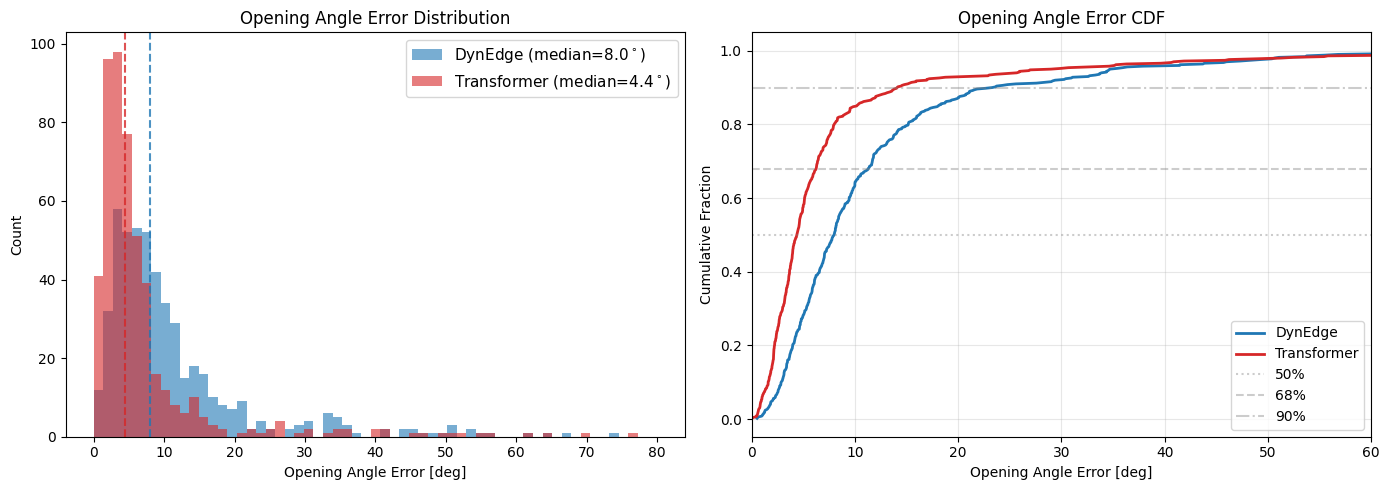

In [3]:
dynedge_opening = dynedge_results["opening_angle_err_deg"].to_numpy()
transformer_opening = transformer_results["opening_angle_deg"].to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Histogram: Opening Angle Error ---
bins = np.linspace(0, 80, 60)
axes[0].hist(dynedge_opening, bins=bins, alpha=0.6, color="tab:blue",
             label=f"DynEdge (median={np.median(dynedge_opening):.1f}$^\\circ$)")
axes[0].hist(transformer_opening, bins=bins, alpha=0.6, color="tab:red",
             label=f"Transformer (median={np.median(transformer_opening):.1f}$^\\circ$)")
axes[0].axvline(np.median(dynedge_opening), color="tab:blue", ls="--", alpha=0.8)
axes[0].axvline(np.median(transformer_opening), color="tab:red", ls="--", alpha=0.8)
axes[0].set_xlabel("Opening Angle Error [deg]")
axes[0].set_ylabel("Count")
axes[0].set_title("Opening Angle Error Distribution")
axes[0].legend(fontsize=11)

# --- CDF ---
x_dyn = np.sort(dynedge_opening)
y_dyn = np.arange(1, len(x_dyn) + 1) / len(x_dyn)
x_tr = np.sort(transformer_opening)
y_tr = np.arange(1, len(x_tr) + 1) / len(x_tr)

axes[1].plot(x_dyn, y_dyn, color="tab:blue", lw=2, label="DynEdge")
axes[1].plot(x_tr, y_tr, color="tab:red", lw=2, label="Transformer")
axes[1].axhline(0.50, color="gray", ls=":", alpha=0.4, label="50%")
axes[1].axhline(0.68, color="gray", ls="--", alpha=0.4, label="68%")
axes[1].axhline(0.90, color="gray", ls="-.", alpha=0.4, label="90%")
axes[1].set_xlabel("Opening Angle Error [deg]")
axes[1].set_ylabel("Cumulative Fraction")
axes[1].set_title("Opening Angle Error CDF")
axes[1].set_xlim(0, 60)
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(TRANSFORMER_DIR / "comparison_opening_angle.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Azimuth / Zenith Fehler (Transformer)

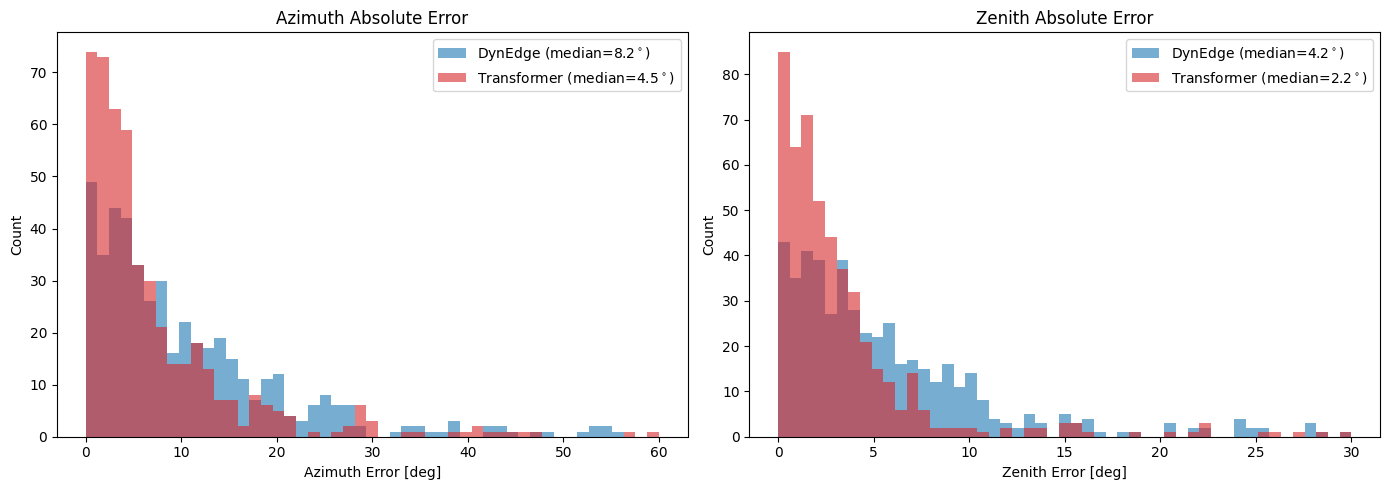

In [4]:
# Azimuth und Zenith Fehler berechnen (Transformer)
tr = transformer_results
az_err_tr = np.degrees(np.abs(np.angle(np.exp(1j * (tr["azimuth_pred"] - tr["azimuth_true"])))))
ze_err_tr = np.degrees(np.abs(tr["zenith_pred"] - tr["zenith_true"]))

# DynEdge hat die Fehler schon berechnet
az_err_dyn = dynedge_results["azimuth_abs_err_deg"].to_numpy()
ze_err_dyn = dynedge_results["zenith_abs_err_deg"].to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Azimuth
bins_az = np.linspace(0, 60, 50)
axes[0].hist(az_err_dyn, bins=bins_az, alpha=0.6, color="tab:blue",
             label=f"DynEdge (median={np.median(az_err_dyn):.1f}$^\\circ$)")
axes[0].hist(az_err_tr, bins=bins_az, alpha=0.6, color="tab:red",
             label=f"Transformer (median={np.median(az_err_tr):.1f}$^\\circ$)")
axes[0].set_xlabel("Azimuth Error [deg]")
axes[0].set_ylabel("Count")
axes[0].set_title("Azimuth Absolute Error")
axes[0].legend()

# Zenith
bins_ze = np.linspace(0, 30, 50)
axes[1].hist(ze_err_dyn, bins=bins_ze, alpha=0.6, color="tab:blue",
             label=f"DynEdge (median={np.median(ze_err_dyn):.1f}$^\\circ$)")
axes[1].hist(ze_err_tr, bins=bins_ze, alpha=0.6, color="tab:red",
             label=f"Transformer (median={np.median(ze_err_tr):.1f}$^\\circ$)")
axes[1].set_xlabel("Zenith Error [deg]")
axes[1].set_ylabel("Count")
axes[1].set_title("Zenith Absolute Error")
axes[1].legend()

plt.tight_layout()
plt.savefig(TRANSFORMER_DIR / "comparison_az_ze.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Opening Angle vs Energy

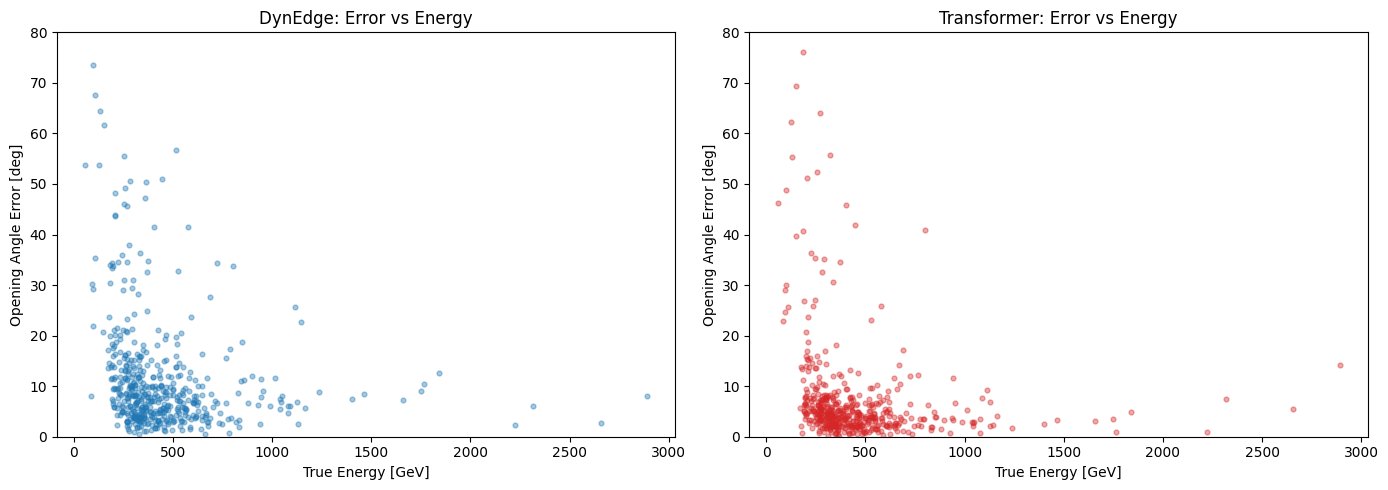

In [5]:
# Beide Modelle haben die gleichen Test-Events (gleicher Split)
# DynEdge hat energy in den Results, Transformer nicht -> aus DynEdge nehmen
# Merge auf event_no
energy = dynedge_results.set_index("event_no")["energy"]
tr_with_energy = transformer_results.set_index("event_no").join(energy, how="inner")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(dynedge_results["energy"], dynedge_opening,
                alpha=0.4, s=12, color="tab:blue")
axes[0].set_xlabel("True Energy [GeV]")
axes[0].set_ylabel("Opening Angle Error [deg]")
axes[0].set_title("DynEdge: Error vs Energy")
axes[0].set_ylim(0, 80)

axes[1].scatter(tr_with_energy["energy"], tr_with_energy["opening_angle_deg"],
                alpha=0.4, s=12, color="tab:red")
axes[1].set_xlabel("True Energy [GeV]")
axes[1].set_ylabel("Opening Angle Error [deg]")
axes[1].set_title("Transformer: Error vs Energy")
axes[1].set_ylim(0, 80)

plt.tight_layout()
plt.savefig(TRANSFORMER_DIR / "comparison_vs_energy.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Transformer Training History

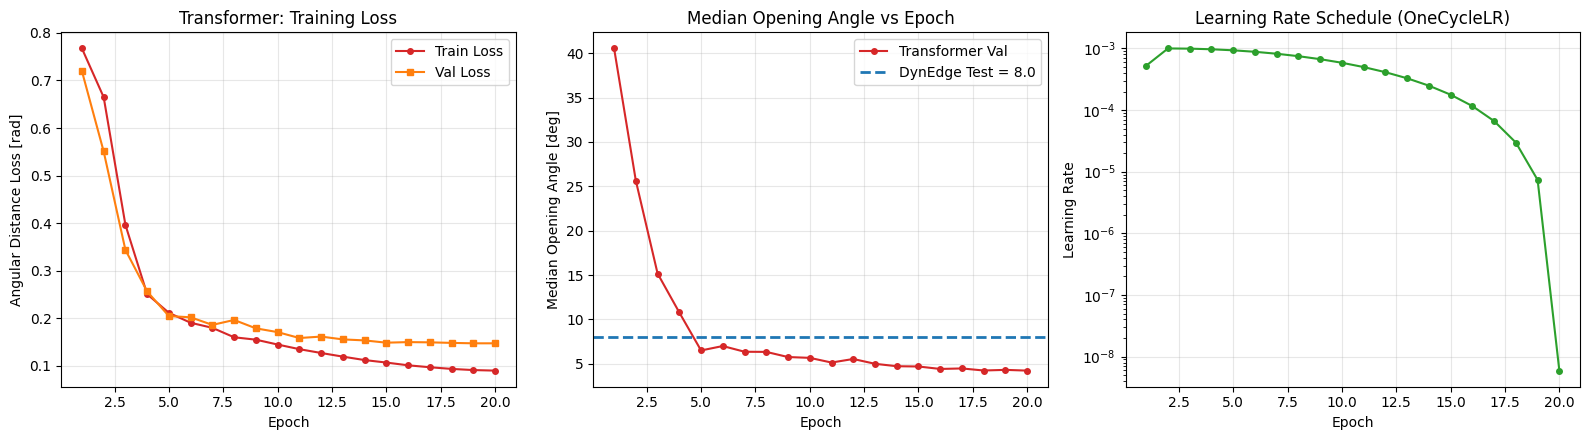

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Loss
axes[0].plot(transformer_history["epoch"], transformer_history["train_loss"],
             "o-", color="tab:red", label="Train Loss", markersize=4)
axes[0].plot(transformer_history["epoch"], transformer_history["val_loss"],
             "s-", color="tab:orange", label="Val Loss", markersize=4)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Angular Distance Loss [rad]")
axes[0].set_title("Transformer: Training Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Median Opening Angle
axes[1].plot(transformer_history["epoch"],
             transformer_history["median_opening_deg"],
             "o-", color="tab:red", markersize=4, label="Transformer Val")
axes[1].axhline(dynedge_metrics["opening_median_deg"], color="tab:blue",
                ls="--", lw=2, label=f"DynEdge Test = {dynedge_metrics['opening_median_deg']:.1f}")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Median Opening Angle [deg]")
axes[1].set_title("Median Opening Angle vs Epoch")
axes[1].legend()
axes[1].grid(alpha=0.3)

# Learning Rate
axes[2].plot(transformer_history["epoch"], transformer_history["lr"],
             "o-", color="tab:green", markersize=4)
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Learning Rate")
axes[2].set_title("Learning Rate Schedule (OneCycleLR)")
axes[2].set_yscale("log")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(TRANSFORMER_DIR / "training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Per-Event Vergleich: Scatter Plot

Transformer besser: 367/500 Events (73.4%)


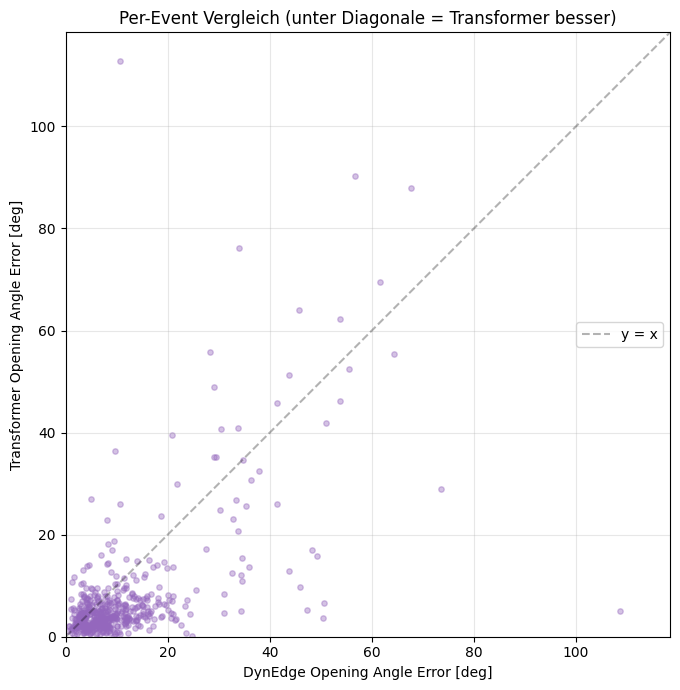

In [7]:
# Per-Event Vergleich: wo ist welches Modell besser?
merged = dynedge_results[["event_no", "opening_angle_err_deg"]].rename(
    columns={"opening_angle_err_deg": "dynedge_deg"}
).merge(
    transformer_results[["event_no", "opening_angle_deg"]].rename(
        columns={"opening_angle_deg": "transformer_deg"}
    ),
    on="event_no",
)

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(merged["dynedge_deg"], merged["transformer_deg"],
           alpha=0.4, s=15, color="tab:purple")
lim = max(merged["dynedge_deg"].max(), merged["transformer_deg"].max()) * 1.05
ax.plot([0, lim], [0, lim], "k--", alpha=0.3, label="y = x")
ax.set_xlabel("DynEdge Opening Angle Error [deg]")
ax.set_ylabel("Transformer Opening Angle Error [deg]")
ax.set_title("Per-Event Vergleich (unter Diagonale = Transformer besser)")
ax.set_xlim(0, lim)
ax.set_ylim(0, lim)
ax.set_aspect("equal")
ax.legend()
ax.grid(alpha=0.3)

n_transformer_better = (merged["transformer_deg"] < merged["dynedge_deg"]).sum()
print(f"Transformer besser: {n_transformer_better}/{len(merged)} Events "
      f"({100*n_transformer_better/len(merged):.1f}%)")

plt.tight_layout()
plt.savefig(TRANSFORMER_DIR / "per_event_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Zusammenfassung

| Metrik | DynEdge | Transformer | Verbesserung |
|--------|---------|-------------|--------------|
| Median Opening Angle | 8.0° | 4.4° | ~45% |
| Mean Opening Angle | 11.5° | 7.8° | ~32% |
| 68%-Quantil | 11.3° | 6.3° | ~45% |
| 90%-Quantil | 23.3° | 14.1° | ~40% |

Der Transformer schlaegt DynEdge auf allen Metriken deutlich, bei gleichem Datensatz und gleichem Split.